In [63]:
%load_ext autoreload
%autoreload 2

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import src.config as cfg
import src.prepareData as prepareData

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
#Version gpu: pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu117

In [ ]:
#Lectura, carga y preparacion del dataset
train_dataset = prepareData.PrepareDataSet(root_dir=cfg.DATASET_ROOT, split="train", scale_factor=cfg.SCALE_FACTOR, patch_size=cfg.PATCH_SIZE)
val_dataset   = prepareData.PrepareDataSet(root_dir=cfg.DATASET_ROOT, split="val",scale_factor=cfg.SCALE_FACTOR, patch_size=cfg.PATCH_SIZE)

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=cfg.NUM_WORKERS, pin_memory=True) # en entrenamiento mezclar el orden de los parches cada epoca nueva
val_loader   = DataLoader(val_dataset,batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True) #pin memory true pues  hago uso de gpu, tenerlo en true usando cpu no tiene mucho sentido

batch = next(iter(train_loader)) #toma el siguiente mini batch del train loader
lr_batch = batch["lr"].to(cfg.DEVICE, non_blocking=True) #[10, 3, 32, 32] -> low resolution
hr_batch = batch["hr"].to(cfg.DEVICE, non_blocking=True) #[10, 3, 128, 128] -> high resolution 

print("Device: ", cfg.DEVICE)


Device:  cpu


Estructura a modelar, cumplirá la funcion de Generador en el modelo.

![Estructura RRDB](./resources/RRDB.png)

Estructura del generador

![Estructura RRDB](./resources/Generator.png)

Consideracion: La imagen anterior es el generador de un modelo SRGAN, lo que estamos modelando es un ESRGAN
por lo que debemos quitar las apariciones de la funcion de activacion BatchNorm y reemplazar los bloques por los nuestros (RRDB).

Estructura del discriminador

![Estructura RRDB](./resources/Discriminador.png)

Se mantiene la misma arquitectura, pero en la evaluación se determina qué tan “relativista” es una imagen para decidir si es real o fake.
Se omite la sigmoide en la evaluacion final porque en SRGAN simplemente determina si es real (1) o fake(0).
En su lugar, la última capa es una convolución que devuelve un mapa 2D de logits.

In [57]:
#Se especifica "we propose animproved perceptual loss by using the VGG features before activation instead of after activation as in SRGAN."

In [58]:
#Podemos proceder a definir todas las cosas que vamos a ocupar para el entrenamiento
from src.generator import RRDBNet
from src.discriminator import Discriminator
from src.vgg_features import VGGFeatureExtractor

generator = RRDBNet(
    in_channels=cfg.IN_CHANNELS,
    out_channels=cfg.OUT_CHANNELS,
    num_features=cfg.NUM_FEATURES,
    growth_channels=cfg.GROWTH_CHANNELS,
    num_blocks=cfg.NUM_BLOCKS,
    scale=cfg.SCALE_FACTOR
).to(cfg.DEVICE)

discriminator = Discriminator(
    in_channels=cfg.IN_CHANNELS, 
    base_channels=cfg.NUM_FEATURES
).to(cfg.DEVICE)

#Optimizadores adam  con los siguientes parametros es lo usual en ESRGAN
optimizer_G = optim.Adam(generator.parameters(), lr=cfg.LR_INITIAL, betas=cfg.BETAS) #Optimizador para el generador
optimizer_D = optim.Adam(discriminator.parameters(), lr=cfg.LR_INITIAL, betas=cfg.BETAS) #Optimizador para el Discrimiandor
pixel_loss = nn.L1Loss().to(cfg.DEVICE)

vgg_extractor = VGGFeatureExtractor(layer_ids=[35], use_input_norm=True, device=cfg.DEVICE).to(cfg.DEVICE)
perceptual_loss = nn.L1Loss().to(cfg.DEVICE) 
bce_loss = nn.BCEWithLogitsLoss().to(cfg.DEVICE) #Probabilidades de real y fake por parte del discriminador





/home/jose/miniconda3/envs/pateaAbuelitas/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jose/miniconda3/envs/pateaAbuelitas/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<p >  
  Fórmula para calcular el error del Discriminador:
</p>
<img src="./resources/formulaLossDis.png" alt="Loss D" width="800"/>
<br>
<p>  
  Fórmula para calcular el error del Generador:
</p>
<img src="./resources/formulaLossGen.png" alt="Loss G" width="800"/>

<p>  
  Donde:
</p>
<img src="./resources/Subformulas.png" alt="Loss G" width="600"/>


In [ ]:


from src.train import train_model

os.makedirs('./checkpoints', exist_ok=True)

if cfg.CONTINUAR_ENTRENAMIENTO:
    print(f"Reanudando entrenamiento desde: {cfg.CHECKPOINT_PATH}")
    checkpoint = torch.load(cfg.CHECKPOINT_PATH, map_location=cfg.DEVICE)
    generator.load_state_dict(checkpoint["G_state_dict"])
    discriminator.load_state_dict(checkpoint["D_state_dict"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    
    epoca_inicial = checkpoint["epoch"]
else:
    print("Iniciando entrenamiento desde cero...")
    epoca_inicial = 0
    os.makedirs('./checkpoints', exist_ok=True)

historial_perdidas = train_model(
    generator=generator, 
    discriminator=discriminator, 
    vgg_extractor=vgg_extractor, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    optimizer_G=optimizer_G, 
    optimizer_D=optimizer_D, 
    bce_loss=bce_loss, 
    pixel_loss=pixel_loss, 
    perceptual_loss=perceptual_loss, 
    device=cfg.DEVICE, 
    num_epochs=10,#cfg.NUM_EPOCHS #Num epochs=150, el 10 es solo para testeo rapido
    start_epoch=epoca_inicial
)


#Con un I511400H 6 nucleos 12 hilos y una rtx 3050 vram (laptop)
#Tomo un total de 8 horas de entrenamiento


Iniciando entrenamiento desde cero...


Epoch [1/10], Pixel: 0.1248, Percep: 0.1690, Color: 0.1331, Tiempo de época: 2.0s
Epoch [2/10], Pixel: 0.3797, Percep: 0.1200, Color: 0.3395, Tiempo de época: 2.1s
Epoch [3/10], Pixel: 0.3171, Percep: 0.2158, Color: 0.3235, Tiempo de época: 2.3s
Epoch [4/10], Pixel: 0.2500, Percep: 0.2094, Color: 0.2816, Tiempo de época: 2.0s
Epoch [5/10], Pixel: 0.2553, Percep: 0.1332, Color: 0.2914, Tiempo de época: 2.0s
Epoch [6/10], Pixel: 0.2066, Percep: 0.1507, Color: 0.2167, Tiempo de época: 2.1s
Epoch [7/10], Pixel: 0.2153, Percep: 0.1383, Color: 0.2094, Tiempo de época: 2.2s
Epoch [8/10], Pixel: 0.1750, Percep: 0.1204, Color: 0.1755, Tiempo de época: 2.0s
Epoch [9/10], Pixel: 0.2759, Percep: 0.1680, Color: 0.2621, Tiempo de época: 2.0s
Epoch [10/10], Pixel: 0.1484, Percep: 0.1071, Color: 0.1421, Tiempo de época: 2.1s
Entrenamiento completado en 21.5s (0.4 minutos).


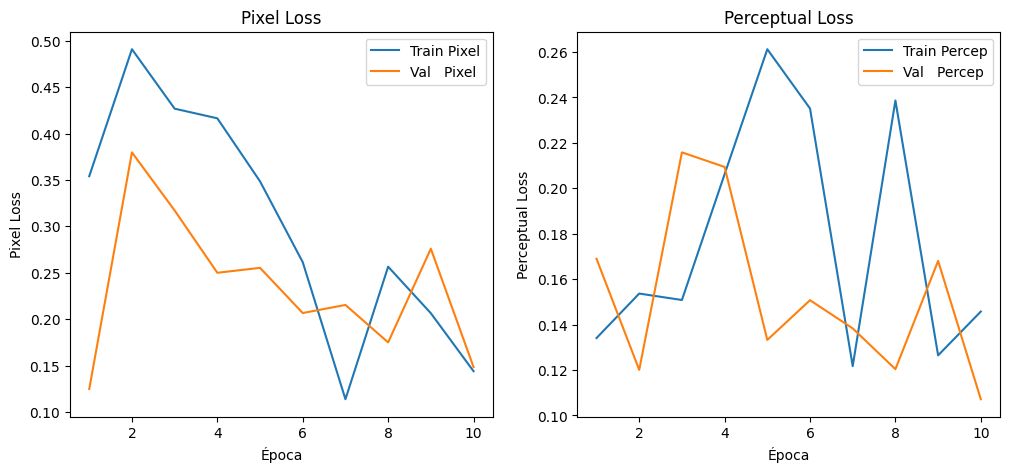

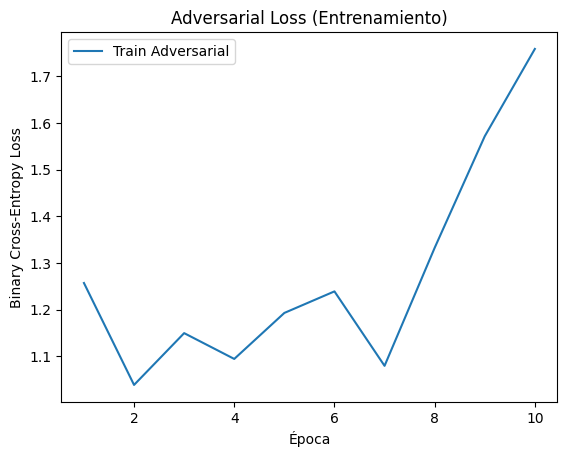

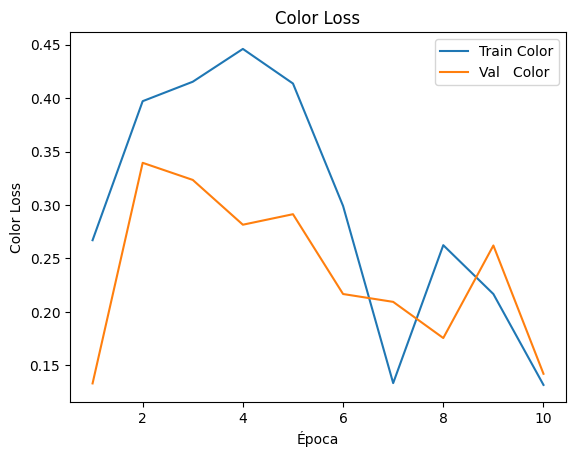

In [60]:

from src.visualize import plot_losses
plot_losses(historial_perdidas, num_epochs=10)#cfg.NUM_EPOCHS)

#Las graficas actuales son muy  poco concluyentes porque modifiqué el dataset con solo 2 imagenes
#univamente para probar codigo, aunque mas abajo adjunté imagenes usando el dataset completo y con 40 epocas

<p>  
  Graficas de error usando 40 epocas:
</p>
<img src="./resources/PixelPerceptualLoss40.png"  width="1000"/>

<img src="./resources/AdversialLoss.png" width="500"/>

<img src="./resources/ColorLoss.png" width="500"/>



In [ ]:


'''Ejecutar esto solo si se quiere aplicar la super resolucion a partir de un checkpoint '''
ckpt = torch.load(cfg.CHECKPOINT_PATH, map_location=cfg.DEVICE)
generator.load_state_dict(ckpt['G_state_dict'])
generator.eval()

/tmp/ipykernel_22986/2305955469.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('./checkpoints/checkpoint_epoch_5.pth', map_location=cfg.DEVICE)


RRDBNet(
  (conv_first): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rrdb_trunk): Sequential(
    (0): RRDB(
      (rdb1): ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv5): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
      )
      (rdb2): ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1

In [ ]:
#Uso final
#asegurarse que la imagen existe

import src.utils as utils
print(f"Procesando imagen: {cfg.TEST_IMAGE_PATH} ...")

sr_image = utils.super_resolve_image(
    model=generator,
    img_path=cfg.TEST_IMAGE_PATH,
    device=cfg.DEVICE,
    scale=cfg.SCALE_FACTOR,
    tile_size=256,
    overlap=0
)

sr_image.save(cfg.OUTPUT_IMAGE_PATH)
print(f"Imagen escalada x4 guardada en: {cfg.OUTPUT_IMAGE_PATH}")

Imagen escalada x4 guardada en: ./scaledImages/ciudadX4_5epocas_lousy.jpg
